## Ignacio Gomez
## Group 3
## Group Assignment Task 3


What are the top 5 industries with the best return over assets per quarter

In [1]:
from pyspark.sql import SparkSession
from collections import namedtuple


In [2]:
# Build SparkSession with conditional configuration
spark = SparkSession.builder.appName("GCSCluster").getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("WARN")

print("✅ Connected to Spark cluster!")
print(f"Spark Version: {sc.version}")
print(f"Master: {sc.master}")
print(f"App ID: {sc.applicationId}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/02 00:15:51 WARN Utils: Your hostname, Ignacios-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.231 instead (on interface en0)
25/12/02 00:15:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 00:15:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/02 00:15:51 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


✅ Connected to Spark cluster!
Spark Version: 4.0.1
Master: local[*]
App ID: local-1764663351999


In [3]:
import argparse

parser = argparse.ArgumentParser()
parser.add_argument(
    "--is-local",
    type=str,
    default="true",
    help="Whether running in local mode",
)

args, unknown = parser.parse_known_args()
is_local = args.is_local.lower() == "true"
if is_local:
    prefix = "../data/processed/merged"
else:
    prefix = "gs://msds-694-cohort-14-3/data"

print(f"Is local environment: {is_local}")

num_csv_path = f"{prefix}/num_2020.csv"
pre_csv_path = f"{prefix}/pre_2020.csv"
sub_csv_path = f"{prefix}/sub_2020.csv"
tag_csv_path = f"{prefix}/tag_2020.csv"

print(f"Num CSV path: {num_csv_path}")
print(f"Pre CSV path: {pre_csv_path}")
print(f"Sub CSV path: {sub_csv_path}")
print(f"Tag CSV path: {tag_csv_path}")

num_rdd = sc.textFile(num_csv_path)
pre_rdd = sc.textFile(pre_csv_path)
sub_rdd = sc.textFile(sub_csv_path)
tag_rdd = sc.textFile(tag_csv_path)

# print size of each RDD
print(f"Num RDD size: {num_rdd.count()}")
print(f"Pre RDD size: {pre_rdd.count()}")
print(f"Sub RDD size: {sub_rdd.count()}")
print(f"Tag RDD size: {tag_rdd.count()}")

Is local environment: True
Num CSV path: ../data/processed/merged/num_2020.csv
Pre CSV path: ../data/processed/merged/pre_2020.csv
Sub CSV path: ../data/processed/merged/sub_2020.csv
Tag CSV path: ../data/processed/merged/tag_2020.csv


Num RDD size: 11493263
Pre RDD size: 2746310
Sub RDD size: 24940
Tag RDD size: 298803


What are the top 5 industries with the best return over assets per quarter?

In [4]:
# parse num line
# adsh,tag,version,ddate,qtrs,uom,segments,coreg,value,footnote,quarter,year
# 0001564590-20-010652,AccountsPayableCurrentAndNoncurrent,us-gaap/2019,20181231,0,USD,,,607000.0,,q1,2020
# 0000753308-20-000021,LongTermDebtCurrent,us-gaap/2019,20181231,0,USD,LegalEntity=NexteraEnergyResources;,NexteraEnergyResources,602000000.0,,q1,2020
# 0001393883-20-000011,RevenueFromContractWithCustomerExcludingAssessedTax,us-gaap/2019,20181231,4,USD,BusinessSegments=Other;,,9312000.0,,q1,2020
# 0001507385-20-000034,StockRedeemedOrCalledDuringPeriodValue,us-gaap/2019,20191231,4,USD,LegalEntity=VEREITOperatingPartnershipL.P.;PartnerCapitalComponents=PreferredStock;PartnerTypeOfPartnersCapitalAccount=GeneralPartner;,,182347000.0,,q1,2020
# 0001564590-20-005569,AvailableForSaleSecuritiesDebtSecurities,us-gaap/2019,20191231,0,USD,FairValueByFairValueHierarchyLevel=FairValueInputsLevel3;FairValueByMeasurementFrequency=FairValueMeasurementsRecurring;FinancialInstrument=MortgageBackedSecurities;,,0.0,,q1,2020
# 0000075252-20-000021,IncreaseDecreaseInOtherOperatingCapitalNet,us-gaap/2019,20191231,4,USD,ConsolidatedEntities=GuarantorSubsidiaries;,,709524000.0,,q1,2020
# 0000024545-20-000005,NetCashProvidedByUsedInFinancingActivities,us-gaap/2019,20191231,4,USD,ConsolidatedEntities=NonGuarantorSubsidiaries;,,-122000000.0,,q1,2020
# 0001402057-20-000042,NetChangeInAccountsPayableInventoryFinancing,0001402057-20-000042,20191231,4,USD,ConsolidatedEntities=SubsidiaryIssuer;ConsolidationItems=ReportableLegalEntities;,,0.0,,q1,2020


# Use namedtuple for better serialization in distributed Spark
NumberEntry = namedtuple(
    "NumberEntry",
    [
        "adsh",
        "tag",
        "version",
        "ddate",
        "quarters",
        "unit_of_measurement",
        "segments",
        "coreg",
        "value",
        "footnote",
        "quarter",
        "year",
    ],
)

parsed_num_rdd = num_rdd.map(lambda line: line.split(",")).map(
    lambda fields: NumberEntry(
        adsh=fields[0],
        tag=fields[1],
        version=fields[2],
        ddate=fields[3],
        quarters=fields[4],
        unit_of_measurement=fields[5],
        segments=fields[6],
        coreg=fields[7],
        value=fields[8],
        footnote=fields[9],
        quarter=fields[10],
        year=fields[11],
    )
)

In [5]:
# pre entry
# adsh,report,line,stmt,inpth,rfile,tag,version,plabel,negating,quarter,year
# 0000002178-20-000013,2,3,BS,0,H,CashAndCashEquivalentsAtCarryingValue,us-gaap/2019,Cash and cash equivalents,0,q1,2020
# 0000002178-20-000013,2,4,BS,0,H,RestrictedCashCurrent,us-gaap/2019,Restricted cash,0,q1,2020
# 0000002178-20-000013,2,5,BS,0,H,AccountsReceivableNetCurrent,us-gaap/2019,"Accounts receivable, net of allowance for doubtful accounts of $141 and $153, respectively",0,q1,2020
# 0000002178-20-000013,2,6,BS,0,H,AccountsReceivableRelatedPartiesCurrent,us-gaap/2019,Accounts receivable  related party,0,q1,2020
PreEntry = namedtuple(
    "PreEntry",
    [
        "adsh",
        "report",
        "line",
        "stmt",
        "inpth",
        "rfile",
        "tag",
        "version",
        "plabel",
        "negating",
        "quarter",
        "year",
    ],
)


In [6]:
# adsh,cik,name,sic,countryba,stprba,cityba,zipba,bas1,bas2,baph,countryma,stprma,cityma,zipma,mas1,mas2,countryinc,stprinc,ein,former,changed,afs,wksi,fye,form,period,fy,fp,filed,accepted,prevrpt,detail,instance,nciks,aciks,quarter,year
# 0000002178-20-000013,2178,"ADAMS RESOURCES & ENERGY, INC.",5172.0,US,TX,HOUSTON,77027,17 S. BRIAR HOLLOW LN.,,713-881-3600,US,TX,HOUSTON,77001,P O BOX 844,,US,DE,741753147.0,ADAMS RESOURCES & ENERGY INC,19920703.0,2-ACC,0,1231.0,10-K,20191231,2019.0,FY,20200306,2020-03-06 16:50:00.0,0,1,ae-20191231_htm.xml,1,,q1,2020
# 0000002488-20-000008,2488,ADVANCED MICRO DEVICES INC,3674.0,US,CA,SANTA CLARA,95054,2485 AUGUSTINE DRIVE,,(408) 749-4000,US,CA,SANTA CLARA,95054,2485 AUGUSTINE DRIVE,,US,DE,941692300.0,,,1-LAF,1,1231.0,10-K,20191231,2019.0,FY,20200204,2020-02-04 17:22:00.0,0,1,amdform10-kfy2019_htm.xml,1,,q1,2020
# 0000002969-20-000010,2969,AIR PRODUCTS & CHEMICALS INC /DE/,2810.0,US,PA,ALLENTOWN,18195-1501,7201 HAMILTON BLVD,,6104814911,US,PA,ALLENTOWN,18195-1501,7201 HAMILTON BLVD,,US,DE,231274455.0,,,1-LAF,0,930.0,10-Q,20191231,2020.0,Q1,20200124,2020-01-24 12:26:00.0,0,1,apd-10qx31dec19_htm.xml,1,,q1,2020
# 0000003499-20-000005,3499,ALEXANDERS INC,6798.0,US,NJ,PARAMUS,07652,210 ROUTE 4 EAST,,201-587-8541,US,NJ,PARAMUS,07652,210 ROUTE 4 EAST,,US,DE,510100517.0,,,1-LAF,1,1231.0,10-K,20191231,2019.0,FY,20200218,2020-02-18 08:21:00.0,0,1,alx10-k123119_htm.xml,1,,q1,2020
# 0000003545-20-000039,3545,"ALICO, INC.",100.0,US,FL,"FT. MYERS,",33913,10070 DANIELS INTERSTATE COURT STE. 100,,239-226-2000,US,FL,"FT. MYERS,",33913,10070 DANIELS INTERSTATE COURT STE. 100,,US,FL,590906081.0,ALICO INC,19920703.0,2-ACC,0,930.0,10-Q,20191231,2020.0,Q1,20200206,2020-02-06 16:46:00.0,0,1,alco-123119x10q_htm.xml,1,,q1,2020
# 0000003570-20-000043,3570,CHENIERE ENERGY INC,4924.0,US,TX,HOUSTON,77002,700 MILAM ST.,SUITE 1900,7133755000,US,TX,HOUSTON,77002,700 MILAM ST.,SUITE 1900,US,DE,954352386.0,CHENIERE ENERGY INC,19960827.0,1-LAF,1,1231.0,10-K,20191231,2019.0,FY,20200225,2020-02-24 18:48:00.0,0,1,cei2019form10k_htm.xml,1,,q1,2020
# 0000004127-20-000007,4127,SKYWORKS SOLUTIONS INC,3674.0,US,MA,WOBURN,01801,20 SYLVAN ROAD,,6179355150,US,MA,WOBURN,01801,20 SYLVAN ROAD,20 SYLVAN ROAD,US,DE,42302115.0,SKYWORKS SOLUTIONS INC,20020627.0,1-LAF,0,930.0,10-Q,20191231,2020.0,Q1,20200124,2020-01-24 16:08:00.0,0,1,q12010qdecember272019_htm.xml,1,,q1,2020
# 0000004281-20-000038,4281,ARCONIC INC.,3350.0,US,PA,PITTSBURGH,15212-5872,201 ISABELLA STREET,SUITE 200,(412) 553-1940,US,NY,NEW YORK,10022-4608,390 PARK AVENUE,,US,DE,250317820.0,ALCOA INC.,20141003.0,1-LAF,1,1231.0,10-K,20191231,2019.0,FY,20200227,2020-02-26 17:49:00.0,0,1,form10k4q19_htm.xml,1,,q1,2020
# 0000004457-20-000027,4457,AMERCO /NV/,7510.0,US,NV,RENO,89511,5555 KIETZKE LANE STE 100,,7756886300,US,NV,RENO,89511,5555 KIETZKE LANE,SUITE 100,US,NV,880106815.0,AMERCO,19770926.0,1-LAF,0,331.0,10-Q,20191231,2020.0,Q3,20200205,2020-02-05 16:06:00.0,0,1,uhal-20191231_htm.xml,1,,q1,2020
# 0000004904-20-000007,4904,AMERICAN ELECTRIC POWER CO INC,4911.0,US,OH,COLUMBUS,43215,1 RIVERSIDE PLAZA,,614-716-1000,US,OH,COLUMBUS,43215,1 RIVERSIDE PLAZA,,US,NY,134922640.0,KINGSPORT UTILITIES INC,19660906.0,1-LAF,1,1231.0,10-K,20191231,2019.0,FY,20200220,2020-02-20 08:53:00.0,0,1,aep10klegal20194q_htm.xml,8,81027 73986 92487 1702494 50172 6879 1721781,q1,2020
# 0000004962-20-000030,4962,AMERICAN EXPRESS CO,6199.0,US,NY,NEW YORK,10285,200 VESEY STREET,50TH FLOOR,2126402000,US,NY,NEW YORK,10285,200 VESEY STREET,50TH FLOOR,US,NY,134922250.0,,,1-LAF,1,1231.0,10-K,20191231,2019.0,FY,20200213,2020-02-13 16:05:00.0,0,1,axp-20191231_htm.xml,1,,q1,2020
# 0000004969-20-000023,4969,AMERICAN EXPRESS CREDIT CORP,6153.0,US,NY,NEW YORK,10285,200 VESEY STREET,,2126402000,US,NY,NEW YORK,10285,200 VESEY STREET,,US,DE,111988350.0,,,4-NON,1,1231.0,10-K,20191231,2019.0,FY,20200227,2020-02-27 16:07:00.0,0,1,aexc-20191231_htm.xml,1,,q1,2020
# 0000004977-20-000044,4977,AFLAC INC,6321.0,US,GA,COLUMBUS,31999,1932 WYNNTON RD,,7063233431,US,GA,COLUMBUS,31999,1932 WYNNTON ROAD,,US,GA,581167100.0,AMERICAN FAMILY CORP,19920306.0,1-LAF,1,1231.0,10-K,20191231,2019.0,FY,20200221,2020-02-21 16:32:00.0,0,1,afl12311910k_htm.xml,1,,q1,2020
# 0000005513-20-000027,5513,UNUM GROUP,6321.0,US,TN,CHATTANOOGA,37402,1 FOUNTAIN SQUARE,,423-294-1011,US,TN,CHATTANOOGA,37402,1 FOUNTAIN SQUARE,,US,DE,621598430.0,UNUMPROVIDENT CORP,19990702.0,1-LAF,1,1231.0,10-K,20191231,2019.0,FY,20200218,2020-02-18 16:34:00.0,0,1,unm-20191231_htm.xml,1,,q1,2020


SubEntry = namedtuple(
    "SubEntry",
    [
        "adsh",
        "cik",
        "name",
        "sic",
        "countryba",
        "stprba",
        "cityba",
        "zipba",
        "bas1",
        "bas2",
        "baph",
        "countryma",
        "stprma",
        "cityma",
        "zipma",
        "mas1",
        "mas2",
        "countryinc",
        "stprinc",
        "ein",
        "former",
        "changed",
        "afs",
        "wksi",
        "fye",
        "form",
        "period",
        "fy",
        "fp",
        "filed",
        "accepted",
        "prevrpt",
        "detail",
        "instance",
        "nciks",
        "aciks",
        "quarter",
        "year",
    ],
)


In [7]:
# tag entry
# tag,version,custom,abstract,datatype,iord,crdr,tlabel,doc,quarter,year
# OperatingLeasesRentExpenseNet,us-gaap/2018,0,0,monetary,D,D,"Operating Leases, Rent Expense, Net","Rental expense for the reporting period incurred under operating leases, including minimum and any contingent rent expense, net of related sublease income.",q1,2020
# OperatingLeaseVariableLeaseIncome,us-gaap/2018,0,0,monetary,D,C,"Operating Lease, Variable Lease Income","Amount of operating lease income from variable lease payments paid and payable to lessor, excluding amount included in measurement of lease receivable.",q1,2020
# OperatingLeaseWeightedAverageDiscountRatePercent,us-gaap/2018,0,0,percent,I,,"Operating Lease, Weighted Average Discount Rate, Percent",Weighted average discount rate for operating lease calculated at point in time.,q1,2020
# DeferredCompensationArrangementWithIndividualCompensationExpense,us-gaap/2018,0,0,monetary,D,D,"Deferred Compensation Arrangement with Individual, Compensation Expense",The compensation expense recognized during the period pertaining to the deferred compensation arrangement.,q1,2020
# DeferredCompensationEquity,us-gaap/2018,0,0,monetary,I,D,Deferred Compensation Equity,"Value of stock issued under share-based plans to employees or officers which is the unearned portion, accounted for under the fair value method.",q1,2020
# DeferredCompensationLiabilityClassifiedNoncurrent,us-gaap/2018,0,0,monetary,I,C,"Deferred Compensation Liability, Classified, Noncurrent","Aggregate carrying value as of the balance sheet date of the liabilities for all deferred compensation arrangements payable beyond one year (or the operating cycle, if longer).",q1,2020
# DeferredCompensationLiabilityCurrent,us-gaap/2018,0,0,monetary,I,C,"Deferred Compensation Liability, Current","Aggregate carrying value as of the balance sheet date of the liabilities for all deferred compensation arrangements payable within one year (or the operating cycle, if longer). Represents currently earned compensation under compensation arrangements that is not actually paid until a later date.",q1,2020
# DeferredCompensationLiabilityCurrentAndNoncurrent,us-gaap/2018,0,0,monetary,I,C,"Deferred Compensation Liability, Current and Noncurrent",Aggregate carrying value as of the balance sheet date of the liabilities for all deferred compensation arrangements. Represents currently earned compensation under compensation arrangements that is not actually paid until a later date.,q1,2020
# OriginationOfLoansToEmployeeStockOwnershipPlans,us-gaap/2018,0,0,monetary,D,C,Origination of Loans to Employee Stock Ownership Plans,"The cash outflow to finance the entity's defined contribution plan to acquire shares of the entity. The plan initially holds the shares in a suspense account, which is collateral for the loan. As the plan makes payment on the debt, the shares are released from the suspense account and become available to be allocated to participant accounts.",q1,2020


TagEntry = namedtuple(
    "TagEntry",
    [
        "tag",
        "version",
        "custom",
        "abstract",
        "datatype",
        "iord",
        "crdr",
        "tlabel",
        "doc",
        "quarter",
        "year",
    ],
)


In [8]:
parsed_num_rdd = num_rdd.map(lambda line: line.split(",")).map(
    lambda fields: NumberEntry(
        adsh=fields[0],
        tag=fields[1],
        version=fields[2],
        ddate=fields[3],
        quarters=fields[4],
        unit_of_measurement=fields[5],
        segments=fields[6],
        coreg=fields[7],
        value=fields[8],
        footnote=fields[9],
        quarter=fields[10],
        year=fields[11],
    )
)

parsed_sub_rdd = sub_rdd.map(lambda line: line.split(",")).map(
    lambda fields: SubEntry(
        adsh=fields[0],
        cik=fields[1],
        name=fields[2],
        sic=fields[3],
        countryba=fields[4],
        stprba=fields[5],
        cityba=fields[6],
        zipba=fields[7],
        bas1=fields[8],
        bas2=fields[9],
        baph=fields[10],
        countryma=fields[11],
        stprma=fields[12],
        cityma=fields[13],
        zipma=fields[14],
        mas1=fields[15],
        mas2=fields[16],
        countryinc=fields[17],
        stprinc=fields[18],
        ein=fields[19],
        former=fields[20],
        changed=fields[21],
        afs=fields[22],
        wksi=fields[23],
        fye=fields[24],
        form=fields[25],
        period=fields[26],
        fy=fields[27],
        fp=fields[28],
        filed=fields[29],
        accepted=fields[30],
        prevrpt=fields[31],
        detail=fields[32],
        instance=fields[33],
        nciks=fields[34],
        aciks=fields[35],
        quarter=fields[36],
        year=fields[37],
    )
)

parsed_pre_rdd = pre_rdd.map(lambda line: line.split(",")).map(
    lambda fields: PreEntry(
        adsh=fields[0],
        report=fields[1],
        line=fields[2],
        stmt=fields[3],
        inpth=fields[4],
        rfile=fields[5],
        tag=fields[6],
        version=fields[7],
        plabel=fields[8],
        negating=fields[9],
        quarter=fields[10],
        year=fields[11],
    )
)

parsed_tag_rdd = tag_rdd.map(lambda line: line.split(",")).map(
    lambda fields: TagEntry(
        tag=fields[0],
        version=fields[1],
        custom=fields[2],
        abstract=fields[3],
        datatype=fields[4],
        iord=fields[5],
        crdr=fields[6],
        tlabel=fields[7],
        doc=fields[8],
        quarter=fields[9],
        year=fields[10],
    )
)


for entry in parsed_num_rdd.take(5):
    print(
        f"ADSH: {entry.adsh}, Tag: {entry.tag}, Date: {entry.ddate}, Value: {entry.value}"
    )
for entry in parsed_sub_rdd.take(5):
    print(f"ADSH: {entry.adsh}, CIK: {entry.cik}, Name: {entry.name}")

for entry in parsed_pre_rdd.take(5):
    print(f"ADSH: {entry.adsh}, Tag: {entry.tag}, Plabel: {entry.plabel}")

for entry in parsed_tag_rdd.take(5):
    print(f"Tag: {entry.tag}, TLabel: {entry.tlabel}, Doc: {entry.doc}")

ADSH: adsh, Tag: tag, Date: ddate, Value: value
ADSH: 0001564590-20-010652, Tag: AccountsPayableCurrentAndNoncurrent, Date: 20181231, Value: 607000.0
ADSH: 0000753308-20-000021, Tag: LongTermDebtCurrent, Date: 20181231, Value: 602000000.0
ADSH: 0001393883-20-000011, Tag: RevenueFromContractWithCustomerExcludingAssessedTax, Date: 20181231, Value: 9312000.0
ADSH: 0001507385-20-000034, Tag: StockRedeemedOrCalledDuringPeriodValue, Date: 20191231, Value: 182347000.0
ADSH: adsh, CIK: cik, Name: name
ADSH: 0000002178-20-000013, CIK: 2178, Name: "ADAMS RESOURCES & ENERGY
ADSH: 0000002488-20-000008, CIK: 2488, Name: ADVANCED MICRO DEVICES INC
ADSH: 0000002969-20-000010, CIK: 2969, Name: AIR PRODUCTS & CHEMICALS INC /DE/
ADSH: 0000003499-20-000005, CIK: 3499, Name: ALEXANDERS INC
ADSH: adsh, Tag: tag, Plabel: plabel
ADSH: 0000002178-20-000013, Tag: CashAndCashEquivalentsAtCarryingValue, Plabel: Cash and cash equivalents
ADSH: 0000002178-20-000013, Tag: RestrictedCashCurrent, Plabel: Restricted c

In [9]:
# define the tags we are interested in for income and assets
net_income_desired_tag_list = [
    "NetIncomeLoss",
    # "ProfitLoss",
    # "NetIncomeLossAvailableToCommonStockholdersBasic",
    # "NetIncomeLossAvailableToCommonStockholdersDiluted",
]
asset_tags = [
    "Assets",
    # "CashAndCashEquivalentsAtCarryingValue",
    # "AccountsReceivableNetCurrent",
    # "InventoryNet",
    # "PropertyPlantAndEquipmentNet",
    # "Goodwill",
    # "IntangibleAssetsNetExcludingGoodwill",
    # "LongTermInvestments",
]


In [10]:
filtered_num_next_income_rdd = (
    parsed_num_rdd.filter(lambda x: x.tag in net_income_desired_tag_list)
    .filter(lambda x: x.unit_of_measurement == "USD")  # filter for USD unit
    .filter(lambda x: x.coreg == "")  # no subsidiaries)
    .filter(lambda x: x.segments == "")  # no segments
    .filter(lambda x: x.value != "")  # value is not empty
)

for record in filtered_num_next_income_rdd.take(5):
    print(
        f"ADSH: {record.adsh}, Tag: {record.tag}, Value: {record.value}, Quarter: {record.quarter}"
    )

ADSH: 0001239819-20-000032, Tag: NetIncomeLoss, Value: 11004241.0, Quarter: q1
ADSH: 0001572758-20-000018, Tag: NetIncomeLoss, Value: 3209000.0, Quarter: q1
ADSH: 0001564590-20-009164, Tag: NetIncomeLoss, Value: 8997000.0, Quarter: q1
ADSH: 0001628280-20-003720, Tag: NetIncomeLoss, Value: -45120000.0, Quarter: q1
ADSH: 0001404912-20-000006, Tag: NetIncomeLoss, Value: 178443000.0, Quarter: q1


In [11]:
filtered_sub_rdd = (
    parsed_sub_rdd.filter(lambda x: x.sic != "")  # industry code is not empty
    .filter(lambda x: x.form in ["10-K", "10-Q"])  # form type is 10-K or 10-Q
    .filter(lambda x: x.countryba == "US")  # country is US
)

In [12]:
filtered_pre_rdd = parsed_pre_rdd.filter(
    lambda x: x.tag in net_income_desired_tag_list
).filter(lambda x: x.stmt in ["IS", "BS"])

print(filtered_pre_rdd.take(5))

[PreEntry(adsh='0000002178-20-000013', report='4', line='29', stmt='IS', inpth='0', rfile='H', tag='NetIncomeLoss', version='us-gaap/2019', plabel='Net (losses) earnings', negating='0', quarter='q1', year='2020'), PreEntry(adsh='0000002488-20-000008', report='2', line='13', stmt='IS', inpth='0', rfile='H', tag='NetIncomeLoss', version='us-gaap/2019', plabel='Net income (loss)', negating='0', quarter='q1', year='2020'), PreEntry(adsh='0000002969-20-000010', report='2', line='15', stmt='IS', inpth='0', rfile='H', tag='NetIncomeLoss', version='us-gaap/2019', plabel='Net Income Attributable to Air Products', negating='0', quarter='q1', year='2020'), PreEntry(adsh='0000003499-20-000005', report='4', line='13', stmt='IS', inpth='0', rfile='H', tag='NetIncomeLoss', version='us-gaap/2019', plabel='Net income', negating='0', quarter='q1', year='2020'), PreEntry(adsh='0000003545-20-000039', report='4', line='24', stmt='IS', inpth='0', rfile='H', tag='NetIncomeLoss', version='us-gaap/2019', plabe

lets join the filtered num data with the sub rdd data to get access to the industry information

In [13]:
# lets join this data with the sub rdd to get access to the industry information
JoinedIncomeEntry = namedtuple("JoinedIncomeEntry", ["sub", "num", "pre"])


joined_company_income_rdd = (
    filtered_sub_rdd.map(lambda x: (x.adsh, x))
    .join(filtered_num_next_income_rdd.map(lambda x: (x.adsh, x)))
    .join(parsed_pre_rdd.map(lambda x: (x.adsh, x)))
    .map(lambda x: JoinedIncomeEntry(x[1][0][0], x[1][0][1], x[1][1]))
)

for entry in joined_company_income_rdd.take(5):
    print(
        f"ADSH: {entry.sub.adsh}, Name: {entry.sub.name}, SIC: {entry.sub.sic}, Form: {entry.sub.form}, Tag: {entry.num.tag}, Value: {entry.num.value}, Quarter: {entry.num.quarter}, Year: {entry.num.year}"
    )

ADSH: 0001171843-20-003557, Name: BIOCRYST PHARMACEUTICALS INC, SIC: 2836.0, Form: 10-Q, Tag: NetIncomeLoss, Value: -37599000.0, Quarter: q2, Year: 2020
ADSH: 0001171843-20-003557, Name: BIOCRYST PHARMACEUTICALS INC, SIC: 2836.0, Form: 10-Q, Tag: NetIncomeLoss, Value: -37599000.0, Quarter: q2, Year: 2020
ADSH: 0001171843-20-003557, Name: BIOCRYST PHARMACEUTICALS INC, SIC: 2836.0, Form: 10-Q, Tag: NetIncomeLoss, Value: -37599000.0, Quarter: q2, Year: 2020
ADSH: 0001171843-20-003557, Name: BIOCRYST PHARMACEUTICALS INC, SIC: 2836.0, Form: 10-Q, Tag: NetIncomeLoss, Value: -37599000.0, Quarter: q2, Year: 2020
ADSH: 0001171843-20-003557, Name: BIOCRYST PHARMACEUTICALS INC, SIC: 2836.0, Form: 10-Q, Tag: NetIncomeLoss, Value: -37599000.0, Quarter: q2, Year: 2020


Group Assets by company, industry by quarter

In [14]:
JoinedAssetEntry = namedtuple("JoinedAssetEntry", ["sub", "num"])
# group  assets by industry adsh and sum the values
filtered_num_assets_rdd = (
    parsed_num_rdd.filter(lambda x: x.tag in asset_tags)
    .filter(lambda x: x.unit_of_measurement == "USD")  # filter for USD unit
    .filter(lambda x: x.coreg == "")  # no subsidiaries)
    .filter(lambda x: x.segments == "")  # no segments
    .filter(lambda x: x.value != "")  # value is not empty
)

# for record in filtered_num_assets_rdd.take(5):
#     print(
#         f"ADSH: {record.adsh}, Tag: {record.tag}, Value: {record.value}, Quarter: {record.quarter}"
#     )

joined_company_assets_rdd = (
    filtered_sub_rdd.map(lambda x: (x.adsh, x))
    .join(filtered_num_assets_rdd.map(lambda x: (x.adsh, x)))
    .map(lambda x: JoinedAssetEntry(x[1][0], x[1][1]))
)

joined_company_assets_rdd.take(5)
for entry in joined_company_assets_rdd.take(5):
    print(
        f"ADSH: {entry.sub.adsh}, Name: {entry.sub.name}, SIC: {entry.sub.sic}, Form: {entry.sub.form}, Tag: {entry.num.tag}, Value: {entry.num.value}, Quarter: {entry.num.quarter}, Year: {entry.num.year}"
    )

ADSH: 0000015615-20-000005, Name: MASTEC INC, SIC: 1623.0, Form: 10-K, Tag: Assets, Value: 4997006000.0, Quarter: q1, Year: 2020
ADSH: 0000015615-20-000005, Name: MASTEC INC, SIC: 1623.0, Form: 10-K, Tag: Assets, Value: 4439953000.0, Quarter: q1, Year: 2020
ADSH: 0000015615-20-000005, Name: MASTEC INC, SIC: 1623.0, Form: 10-K, Tag: Assets, Value: 4066600000.0, Quarter: q1, Year: 2020
ADSH: 0000019617-20-000257, Name: JPMORGAN CHASE & CO, SIC: 6021.0, Form: 10-K, Tag: Assets, Value: 2622532000000.0, Quarter: q1, Year: 2020
ADSH: 0000019617-20-000257, Name: JPMORGAN CHASE & CO, SIC: 6021.0, Form: 10-K, Tag: Assets, Value: 2533600000000.0, Quarter: q1, Year: 2020


Aggregate all incomes and assets by industry and quarter

In [17]:
aggregated_incomes_rdd = (
    joined_company_income_rdd.map(
        lambda x: (
            (x.sub.sic, x.num.quarter, x.num.year),
            float(x.num.value),
        )
    )
    .reduceByKey(lambda a, b: a + b)
    .map(lambda x: (x[0], x[1]))
    # order by value descending
    .sortBy(lambda x: x[1], ascending=False)
)

aggregated_incomes_rdd.take(5)

# for entry in aggregated_incomes_rdd.take(5):
#     sic, quarter, year = entry[0]
#     total_income = entry[1]
#     print(
#         f"SIC: {sic}, Quarter: {quarter}, Year: {year}, Total Income: {total_income}"
#     )

[(('6021.0', 'q1', '2020'), 52136406935274.0),
 (('6021.0', 'q4', '2020'), 32644941793413.0),
 (('3571.0', 'q4', '2020'), 31027510000000.0),
 (('6331.0', 'q1', '2020'), 30925216757696.0),
 (('6021.0', 'q3', '2020'), 20626964377928.0)]

In [18]:
aggregated_assets_rdd = joined_company_assets_rdd.map(
    lambda x: (
        (x.sub.sic, x.num.quarter, x.num.year),
        float(x.num.value),
    )
).reduceByKey(lambda a, b: a + b)

aggregated_assets_rdd.take(5)

[(('6021.0', 'q2', '2020'), 28625466245512.0),
 (('4911.0', 'q2', '2020'), 1507647767895.0),
 (('6311.0', 'q4', '2020'), 7839456155800.0),
 (('3460.0', 'q2', '2020'), 9444566000.0),
 (('3531.0', 'q4', '2020'), 162584425000.0)]

Calculate return on assets per industry per quarter


In [ ]:
return_on_assets_rdd = (
    aggregated_incomes_rdd.join(aggregated_assets_rdd)
    .map(
        lambda x: (
            (x[0][0], x[0][1], x[0][2]),
            x[1][0] / x[1][1] if x[1][1] != 0 else 0,
        )
    )
    .sortBy(lambda x: x[1], ascending=False)
)

for entry in return_on_assets_rdd.take(10):
    sic, quarter, year = entry[0]
    roa = entry[1]
    print(f"SIC: {sic}, Quarter: {quarter}, Year: {year}, ROA: {roa}")


SIC: 6792.0, Quarter: q1, Year: 2020, ROA: 120.21795389985407
SIC: 5094.0, Quarter: q3, Year: 2020, ROA: 61.1054072185697
SIC: 5094.0, Quarter: q4, Year: 2020, ROA: 59.31981983946004
SIC: 2111.0, Quarter: q1, Year: 2020, ROA: 57.753316488563236
SIC: 6794.0, Quarter: q4, Year: 2020, ROA: 51.3332469439113
SIC: 3585.0, Quarter: q1, Year: 2020, ROA: 48.40412138795041
SIC: 3021.0, Quarter: q2, Year: 2020, ROA: 46.42901409756654
SIC: 6794.0, Quarter: q3, Year: 2020, ROA: 45.8835600585174
SIC: 3751.0, Quarter: q1, Year: 2020, ROA: 42.456301677444706
SIC: 3944.0, Quarter: q1, Year: 2020, ROA: 41.0423217444494


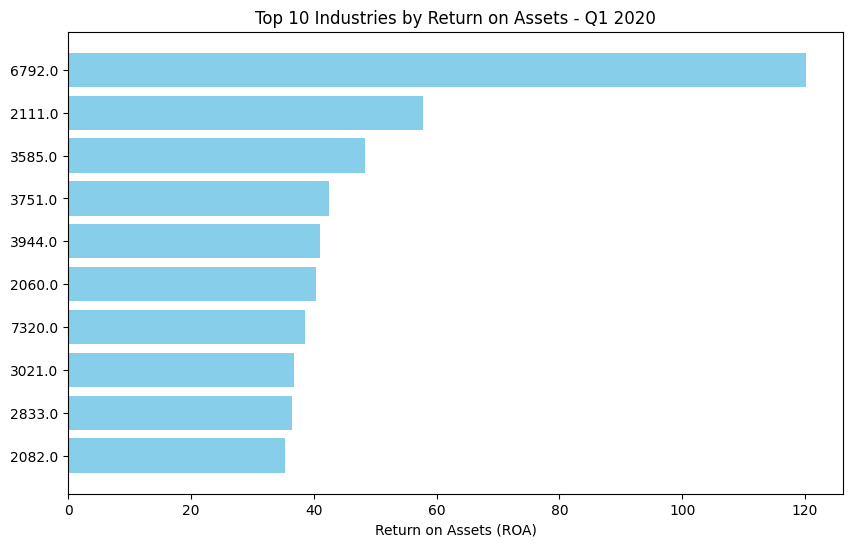

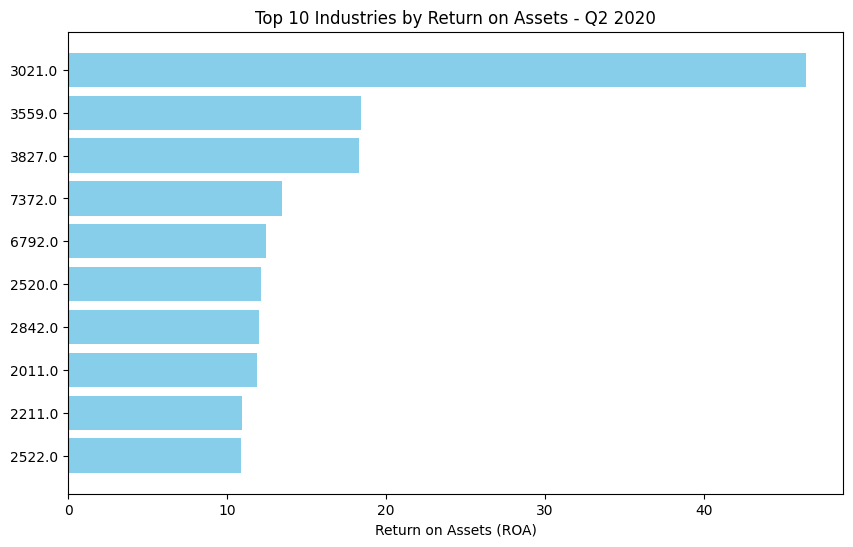

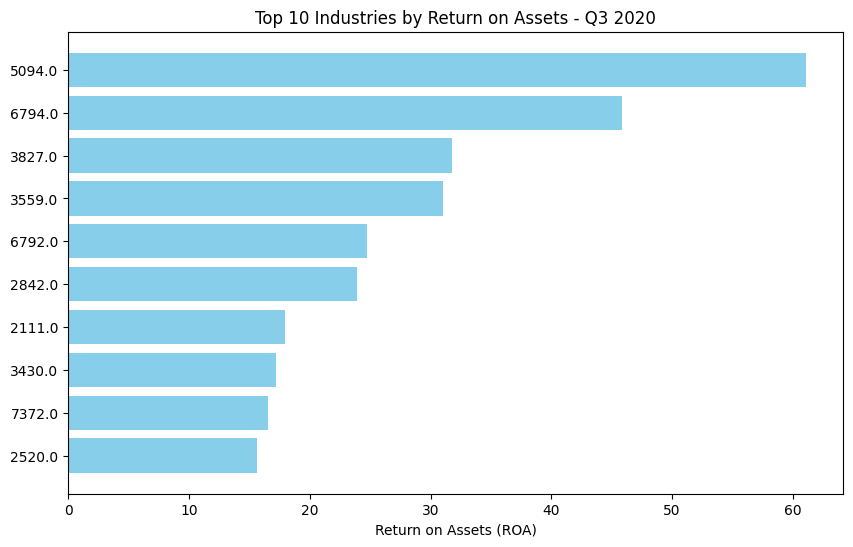

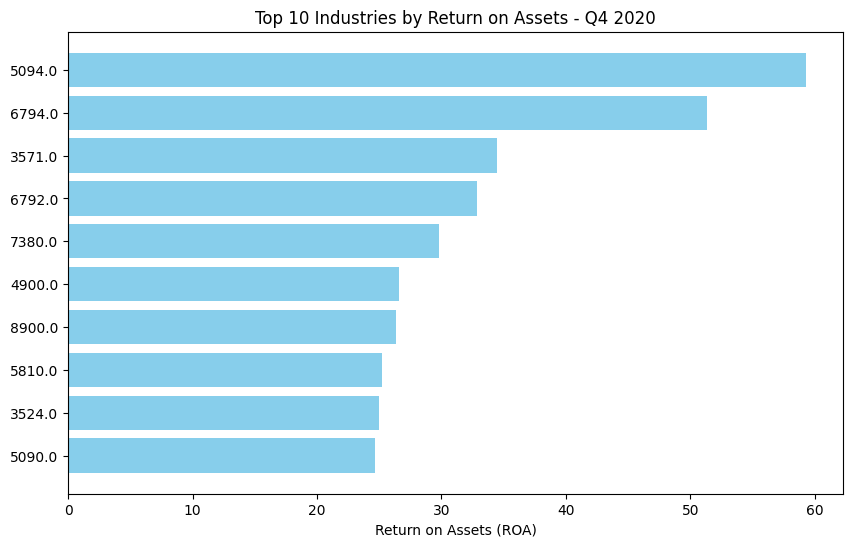

In [24]:
# visualize the top 10 industries by return on assets per quarter using matplotlib

quarters = [
    "q1",
    "q2",
    "q3",
    "q4",
]

import matplotlib.pyplot as plt

for quarter in quarters:
    top_10_roa = return_on_assets_rdd.filter(
        lambda x: x[0][1] == quarter
    ).take(10)

    sic_codes = [entry[0][0] for entry in top_10_roa]
    roa_values = [entry[1] for entry in top_10_roa]

    plt.figure(figsize=(10, 6))
    plt.barh(sic_codes, roa_values, color="skyblue")
    plt.xlabel("Return on Assets (ROA)")
    plt.title(
        f"Top 10 Industries by Return on Assets - {quarter.upper()} 2020"
    )
    plt.gca().invert_yaxis()  # highest ROA on top
    plt.show()